Loaded snapshots:
HJ run snapshots   : 9
CASCA run snapshots: 10

HJ snapshot times (yr): [      0.    1000.    5000.   10000.   50000.  100000.  200000.  500000.
 1000000.]
CASCA snapshot times (yr): [      0.          111111.11111111  222222.22222222  333333.33333333
  444444.44444444  555555.55555556  666666.66666667  777777.77777778
  888888.88888889 1000000.        ]

Loaded initial profiles:
           R: HJ (1000,) | CASCA (1000,)
     Sigma_G: HJ (1000,) | CASCA (1000,)
     Sigma_D: HJ (1000,) | CASCA (1000,)
         eps: HJ (1000,) | CASCA (1000,)
          St: HJ (1000,) | CASCA (1000,)
 pebble_size: HJ (1000,) | CASCA (1000,)
           P: HJ (1000,) | CASCA (1000,)
           T: HJ (1000,) | CASCA (1000,)

Data source and definition notes:
- eps (dust mass fraction): Sigma_D / (Sigma_G + Sigma_D)
- HJ eps: computed from Sigma_dust + Sigma_pebbles (not stored in file)
- CASCA eps: loaded from 'dust_frac' dataset (computed during simulation as disc.dust_frac.sum(axis=0))
- 

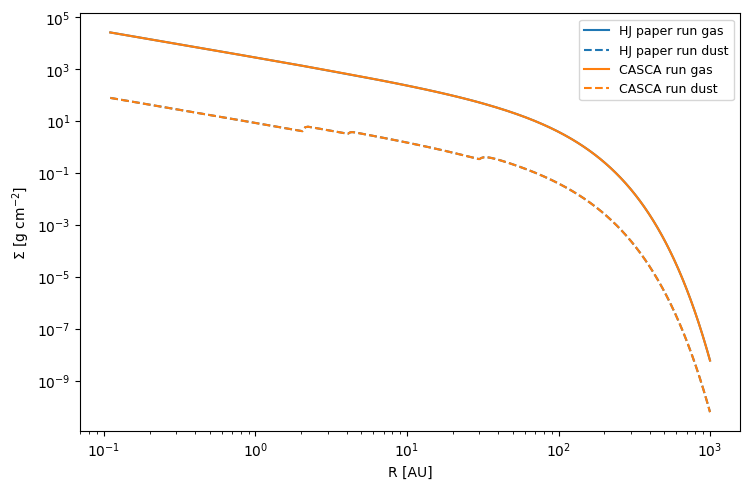

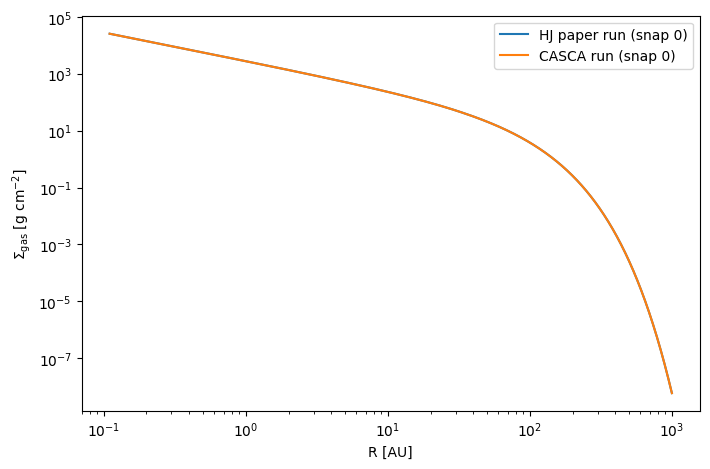

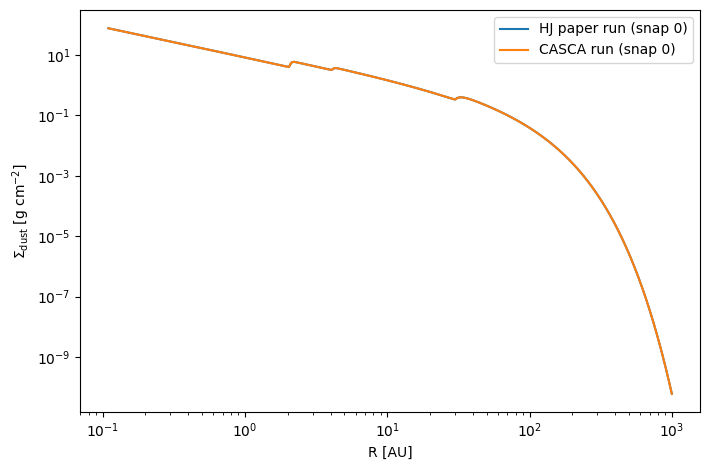

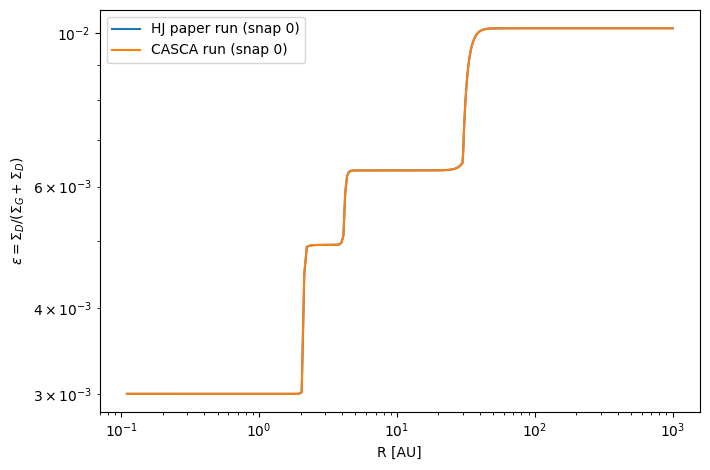

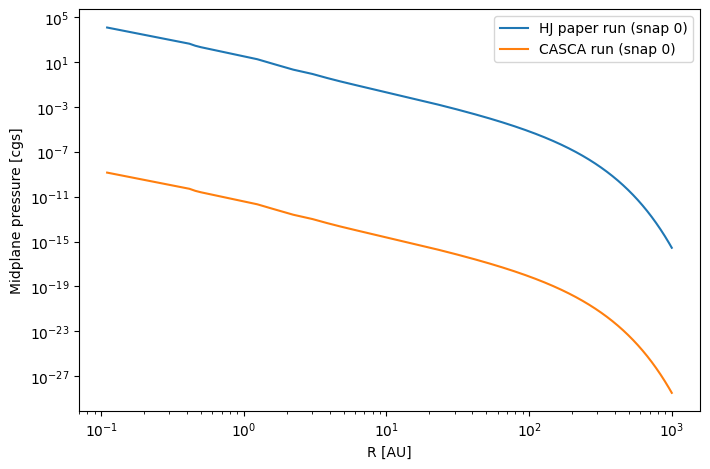

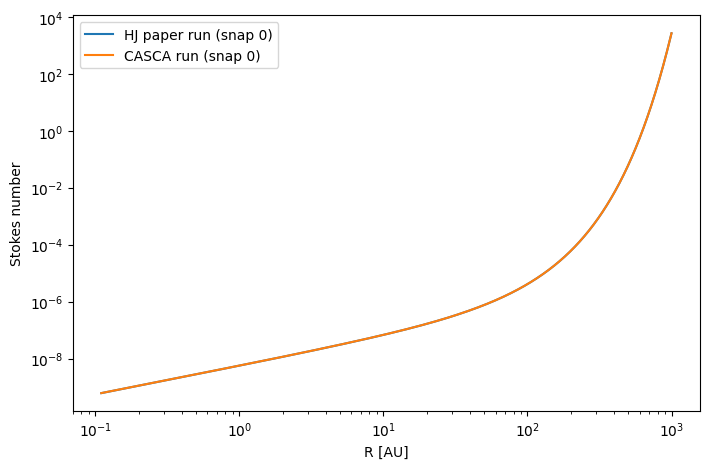

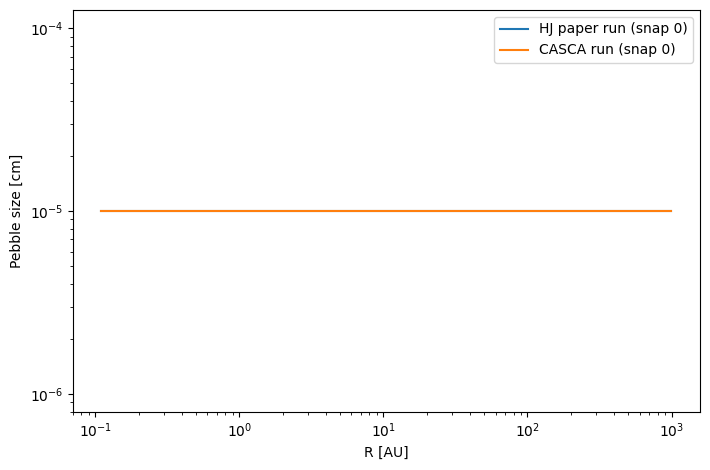

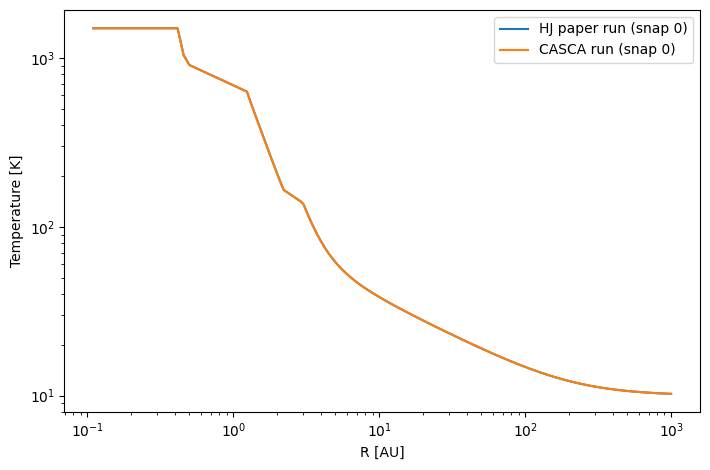

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# HJ_PATH = "/Users/james/Documents/GitHub/DiscEvolution_HJpaper_branch/James/HJ_paper_test_run_results/0.1Myr/winds_mig_psi0.01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01.h5"
# CASCA_PATH = "/Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets_psiConstant copy 8/psi0.01_diskmass_0.10_alphaSS_1e-03_Mdot_1.0e-08/run_data.h5"

# HJ_PATH = "/Users/james/Documents/GitHub/DiscEvolution_HJpaper_branch/James/HJ_paper_test_run_results/0.1Myr_NoPmals/winds_mig_psi0.01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01.h5"
# CASCA_PATH = "/Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets_psiConstant copy 11/implantzero_chemTrue_psi0.01_diskmass_0.10_alphaSS_1e-07_Mdot_1.0e-08/run_data.h5"

# HJ_PATH = "/Users/james/Documents/GitHub/DiscEvolution_HJpaper_branch/James/HJ_paper_test_run_results/1Myr/winds_mig_psi0.01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01.h5"
# CASCA_PATH = "/Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets_psiConstant copy 11/1Myr_implantzero_chemTrue_psi0.01_diskmass_0.10_alphaSS_1e-07_Mdot_1.0e-08/run_data.h5"



# HJ_PATH = "/Users/james/Documents/GitHub/DiscEvolution_HJpaper_branch/James/HJ_paper_test_run_results/JulyRun/winds_mig_psi0.01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01.h5"
HJ_PATH = "/Users/james/Documents/GitHub/DiscEvolution_HJpaper_branch/James/HJ_paper_test_run_results/JulyRun/nu_scaled_with_psi/winds_mig_psi0.01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01.h5"
# CASCA_PATH = "/Users/james/Documents/GitHub/DiscEvolution/james/june2026/output/Comparison_viscous_disc/lambda_1.017_mu2.5_psi0.01_diskmass_0.10_alphaSS_1e-07_Mdot_1.0e-08/run_data.h5" 
CASCA_PATH =  "/Users/james/Documents/GitHub/DiscEvolution/james/june2026/output/Comparison_viscous_disc/lambda_1.017_mu2.4_psi0.01_diskmass_0.10_alphaSS_1e-07_Mdot_1.0e-08/run_data_1.h5"





MU = 2.4
MSTAR_MSUN = 1.0

MSUN_CGS = 1.98847e33
G_CGS = 6.67430e-8
KB_CGS = 1.380649e-16
MP_CGS = 1.67262192369e-24
AU_CGS = 1.495978707e13

def _snapshot(arr, idx):
    arr = np.asarray(arr)
    if arr.ndim >= 2:
        return arr[idx]
    return arr

def _midplane_pressure(Sigma_g, T, R_au, mu=MU, mstar_msun=MSTAR_MSUN):
    R_cgs = np.asarray(R_au) * AU_CGS
    cs = np.sqrt(KB_CGS * np.asarray(T) / (mu * MP_CGS))
    omega = np.sqrt(G_CGS * (mstar_msun * MSUN_CGS) / np.maximum(R_cgs**3, 1e-300))
    H = cs / np.maximum(omega, 1e-300)
    rho_mid = np.asarray(Sigma_g) / (np.sqrt(2.0 * np.pi) * np.maximum(H, 1e-300))
    return rho_mid * cs**2

def load_hj_run(path):
    with h5py.File(path, "r") as f:
        R = np.asarray(f["R"])
        Sigma_G = np.asarray(f["Sigma_G"])
        Sigma_dust = np.asarray(f["Sigma_dust"])
        Sigma_pebbles = np.asarray(f["Sigma_pebbles"])
        Sigma_D = Sigma_dust + Sigma_pebbles
        T = np.asarray(f["T"])
        pebble_size = np.asarray(f["Sigma_pebble_size"])
        St = (np.pi / 2.0) * pebble_size / np.maximum(Sigma_G, 1e-300)
        # Compute dust mass fraction: eps = Sigma_D / (Sigma_G + Sigma_D)
        eps = Sigma_D / (Sigma_G + np.maximum(Sigma_D, 1e-300))
        P = _midplane_pressure(Sigma_G, T, R)
        # Load snapshot times (in Myr, convert to years)
        time_snap = np.asarray(f["time_snap"]) * 1e6 if "time_snap" in f else None

    return {
        "label": "HJ paper run",
        "path": path,
        "R": R,
        "n_snap": Sigma_G.shape[0],
        "times": time_snap,
        "Sigma_G_all": Sigma_G,
        "Sigma_D_all": Sigma_D,
        "Sigma_dust_all": Sigma_dust,
        "Sigma_pebbles_all": Sigma_pebbles,
        "T_all": T,
        "pebble_size_all": pebble_size,
        "St_all": St,
        "eps_all": eps,
        "P_all": P,
    }

def load_casca_run(path):
    with h5py.File(path, "r") as f:
        R = np.asarray(f["R"])
        Sigma_G = np.asarray(f["Sigma_G"])
        Sigma_D = np.asarray(f["Sigma_D"])
        T = np.asarray(f["T"])
        St = np.asarray(f["St"])
        pebble_size = np.asarray(f["grain_size"])
        # Load dust mass fraction directly from HDF5 file
        # dust_frac = Sigma_D / (Sigma_G + Sigma_D), stored as 'dust_frac' during simulation
        if "dust_frac" in f:
            eps = np.asarray(f["dust_frac"])
        else:
            eps = Sigma_D / (Sigma_G + np.maximum(Sigma_D, 1e-300))
        if "P" in f:
            P = np.asarray(f["P"])
        else:
            P = _midplane_pressure(Sigma_G, T, R)
        # Load snapshot times (in years)
        times = np.asarray(f["t_yr"]) if "t_yr" in f else None

    return {
        "label": "CASCA run",
        "path": path,
        "R": R,
        "n_snap": Sigma_G.shape[0],
        "times": times,
        "Sigma_G_all": Sigma_G,
        "Sigma_D_all": Sigma_D,
        "Sigma_dust_all": None,
        "Sigma_pebbles_all": None,
        "T_all": T,
        "pebble_size_all": pebble_size,
        "St_all": St,
        "eps_all": eps,
        "P_all": P,
    }

def get_snapshot(run, idx=0):
    if idx < 0 or idx >= run["n_snap"]:
        raise IndexError(f"{run['label']} snapshot index {idx} is out of range [0, {run['n_snap'] - 1}]")
    return {
        "label": run["label"],
        "idx": idx,
        "R": run["R"],
        "Sigma_G": _snapshot(run["Sigma_G_all"], idx),
        "Sigma_D": _snapshot(run["Sigma_D_all"], idx),
        "T": _snapshot(run["T_all"], idx),
        "St": _snapshot(run["St_all"], idx),
        "pebble_size": _snapshot(run["pebble_size_all"], idx),
        "eps": _snapshot(run["eps_all"], idx),
        "P": _snapshot(run["P_all"], idx),
    }

def compare_single_profile(run_a_snap, run_b_snap, key, ylabel=None, logy=True):
    plt.figure(figsize=(7.2, 4.8))
    plt.plot(run_a_snap["R"], run_a_snap[key], label=f"{run_a_snap['label']} (snap {run_a_snap['idx']})")
    plt.plot(run_b_snap["R"], run_b_snap[key], label=f"{run_b_snap['label']} (snap {run_b_snap['idx']})")
    plt.xscale("log")
    if logy:
        plt.yscale("log")
    plt.xlabel("R [AU]")
    plt.ylabel(ylabel if ylabel else key)
    plt.legend()
    plt.tight_layout()
    plt.show()

def compare_sigma_components(run_a_snap, run_b_snap):
    plt.figure(figsize=(7.6, 5.0))
    plt.plot(run_a_snap["R"], run_a_snap["Sigma_G"], color="C0", linestyle="-", label=f"{run_a_snap['label']} gas")
    plt.plot(run_a_snap["R"], run_a_snap["Sigma_D"], color="C0", linestyle="--", label=f"{run_a_snap['label']} dust")
    plt.plot(run_b_snap["R"], run_b_snap["Sigma_G"], color="C1", linestyle="-", label=f"{run_b_snap['label']} gas")
    plt.plot(run_b_snap["R"], run_b_snap["Sigma_D"], color="C1", linestyle="--", label=f"{run_b_snap['label']} dust")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("R [AU]")
    plt.ylabel(r"$\Sigma$ [g cm$^{-2}$]")
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

hj_run = load_hj_run(HJ_PATH)
casca_run = load_casca_run(CASCA_PATH)

print("Loaded snapshots:")
print(f"HJ run snapshots   : {hj_run['n_snap']}")
print(f"CASCA run snapshots: {casca_run['n_snap']}")

if hj_run['times'] is not None:
    print(f"\nHJ snapshot times (yr): {hj_run['times']}")
if casca_run['times'] is not None:
    print(f"CASCA snapshot times (yr): {casca_run['times']}")

hj0 = get_snapshot(hj_run, 0)
casca0 = get_snapshot(casca_run, 0)

print("\nLoaded initial profiles:")
for key in ["R", "Sigma_G", "Sigma_D", "eps", "St", "pebble_size", "P", "T"]:
    print(f"{key:>12s}: HJ {hj0[key].shape} | CASCA {casca0[key].shape}")

print("\nData source and definition notes:")
print("- eps (dust mass fraction): Sigma_D / (Sigma_G + Sigma_D)")
print("- HJ eps: computed from Sigma_dust + Sigma_pebbles (not stored in file)")
print("- CASCA eps: loaded from 'dust_frac' dataset (computed during simulation as disc.dust_frac.sum(axis=0))")
print("- HJ P: reconstructed from Sigma_G, T, and physics formula")
print("- CASCA P: loaded from HDF5 file (computed during simulation as disc.P)")

compare_sigma_components(hj0, casca0)
compare_single_profile(hj0, casca0, "Sigma_G", ylabel=r"$\Sigma_\mathrm{gas}$ [g cm$^{-2}$]")
compare_single_profile(hj0, casca0, "Sigma_D", ylabel=r"$\Sigma_\mathrm{dust}$ [g cm$^{-2}$]")
compare_single_profile(hj0, casca0, "eps", ylabel=r"$\epsilon = \Sigma_D / (\Sigma_G + \Sigma_D)$")
compare_single_profile(hj0, casca0, "P", ylabel="Midplane pressure [cgs]")
compare_single_profile(hj0, casca0, "St", ylabel="Stokes number")
compare_single_profile(hj0, casca0, "pebble_size", ylabel="Pebble size [cm]")
compare_single_profile(hj0, casca0, "T", ylabel="Temperature [K]")


Comparing snapshots: HJ=0, CASCA=0


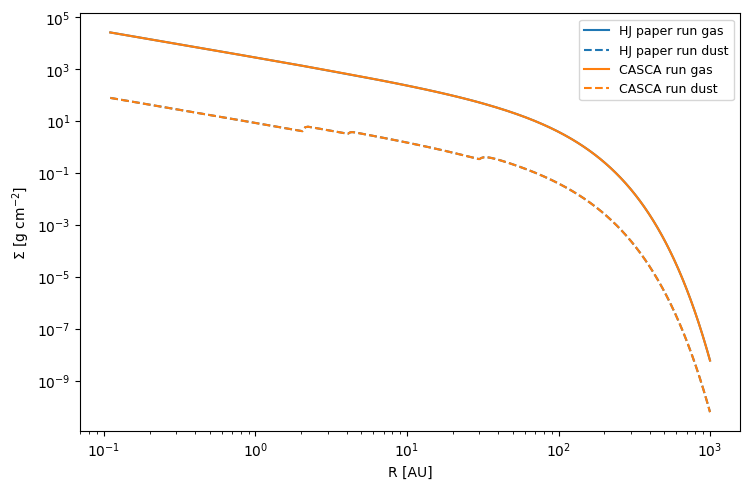

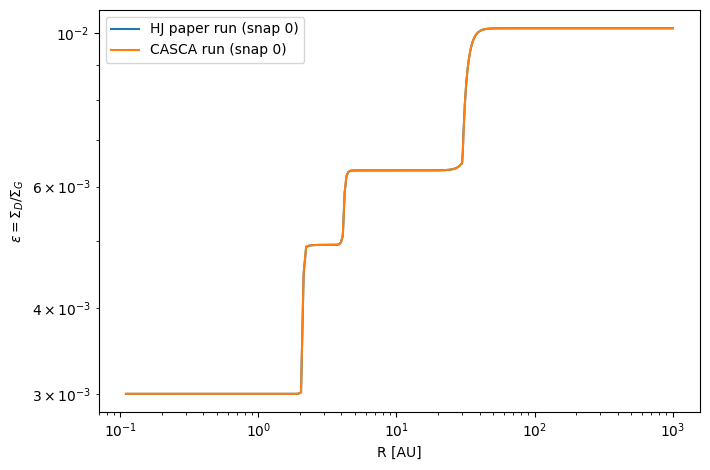

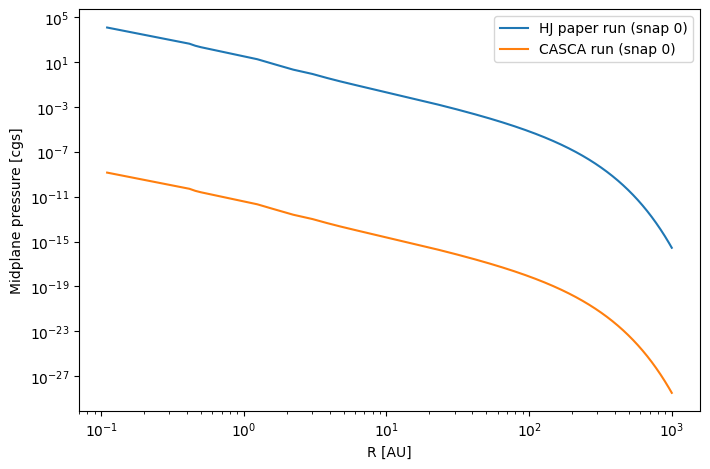

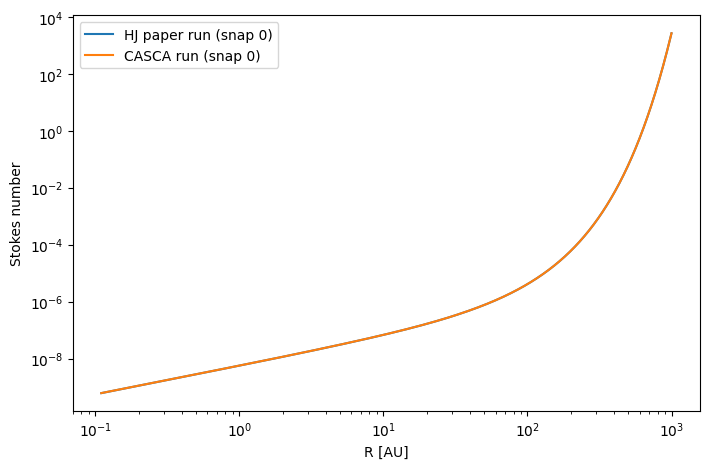

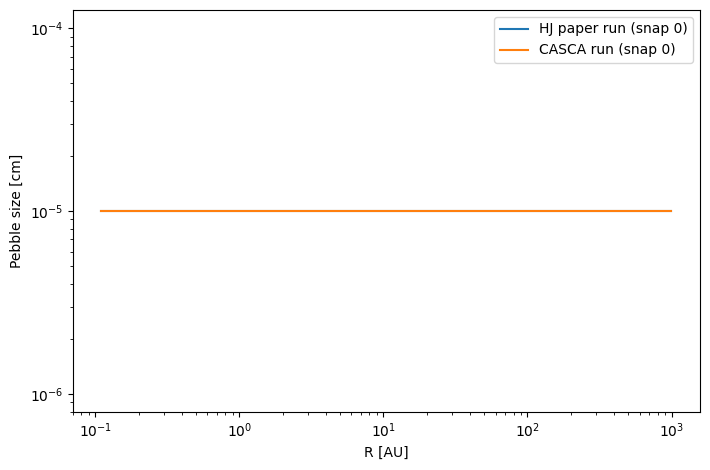

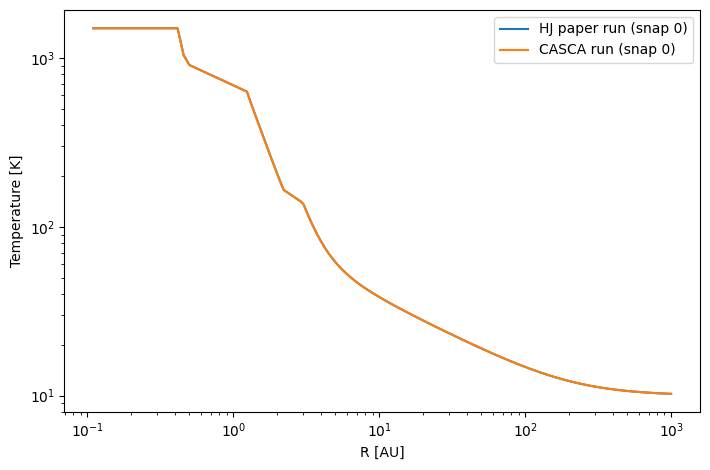

In [2]:
# Choose snapshot index for each run (0-based).
HJ_SNAPSHOT_IDX = 0
CASCA_SNAPSHOT_IDX = 0

hj_snap = get_snapshot(hj_run, HJ_SNAPSHOT_IDX)
casca_snap = get_snapshot(casca_run, CASCA_SNAPSHOT_IDX)

print(f"Comparing snapshots: HJ={HJ_SNAPSHOT_IDX}, CASCA={CASCA_SNAPSHOT_IDX}")

# Gas solid and dust dashed on the same axes for both runs
compare_sigma_components(hj_snap, casca_snap)

# Additional profile comparisons at chosen snapshots
compare_single_profile(hj_snap, casca_snap, "eps", ylabel=r"$\epsilon = \Sigma_D / \Sigma_G$")
compare_single_profile(hj_snap, casca_snap, "P", ylabel="Midplane pressure [cgs]")
compare_single_profile(hj_snap, casca_snap, "St", ylabel="Stokes number")
compare_single_profile(hj_snap, casca_snap, "pebble_size", ylabel="Pebble size [cm]")
compare_single_profile(hj_snap, casca_snap, "T", ylabel="Temperature [K]")

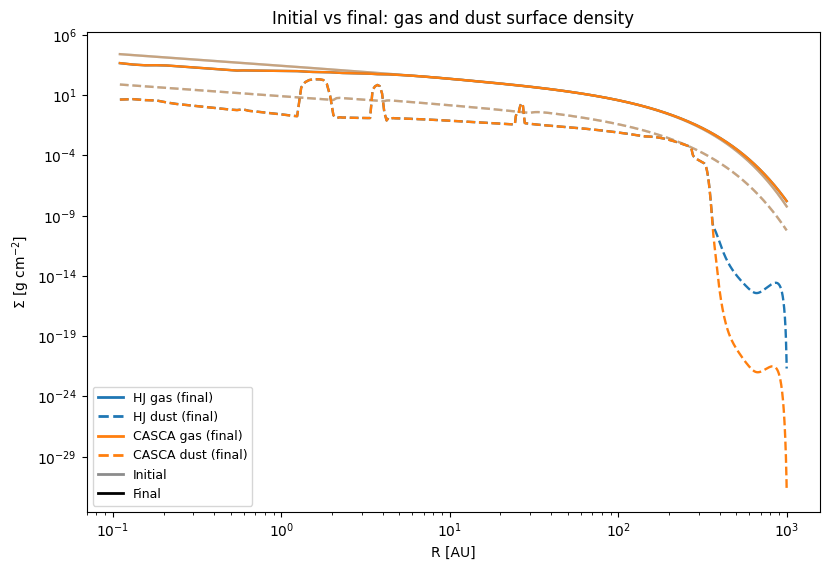

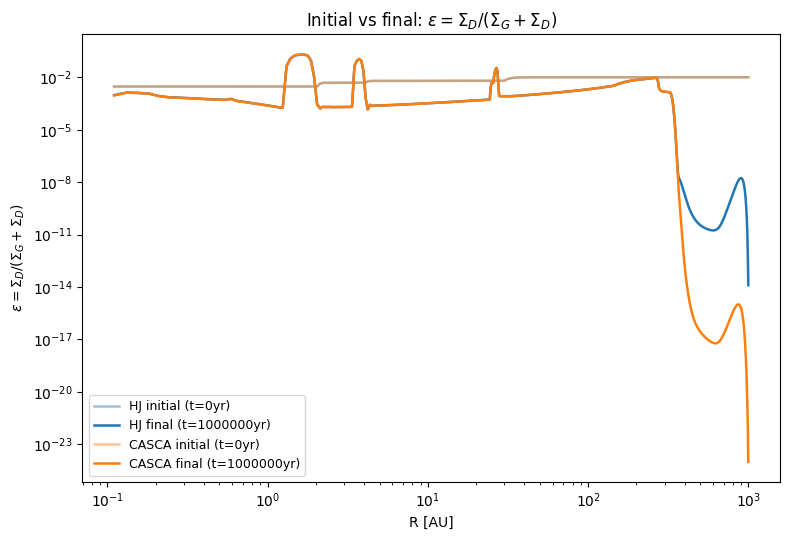

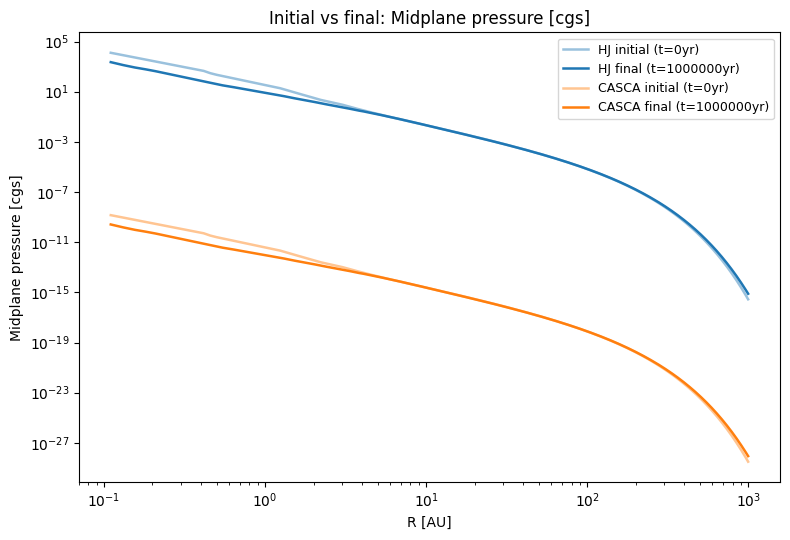

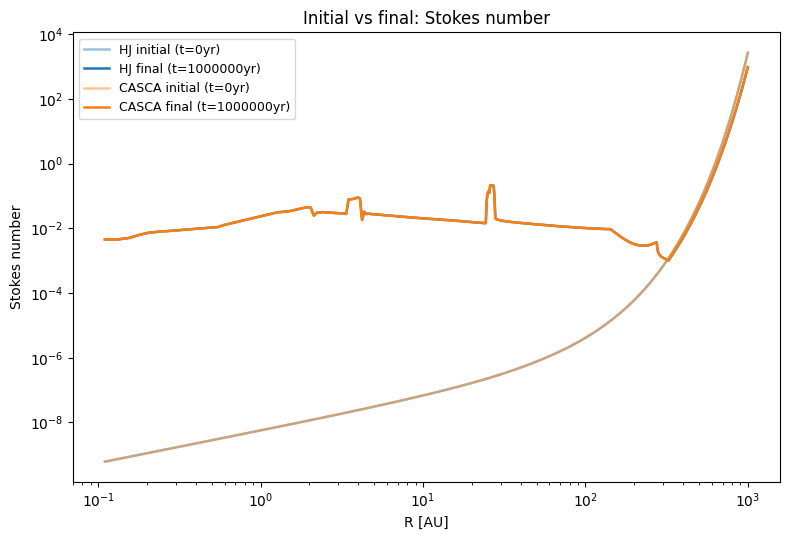

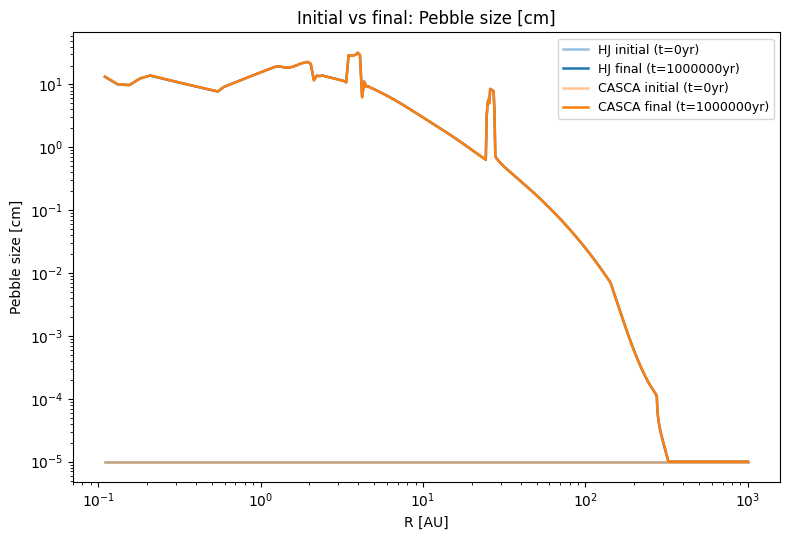

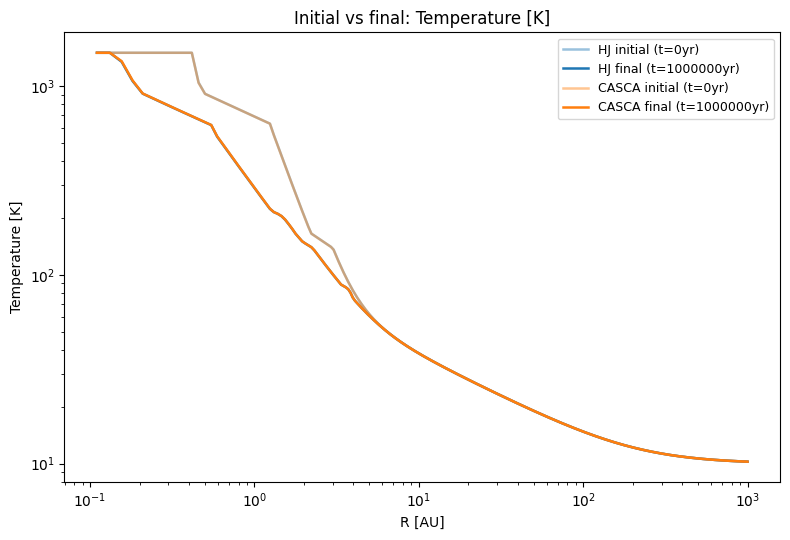

In [3]:
def _initial_final_indices(n):
    if n <= 1:
        return [0]
    return [0, n - 1]


def plot_evolution_overlay(key, ylabel, logy=True):
    fig, ax = plt.subplots(figsize=(8.0, 5.5))

    hj_idx = _initial_final_indices(hj_run["n_snap"])
    casca_idx = _initial_final_indices(casca_run["n_snap"])

    # HJ run: initial/final only (blue)
    for i, a in zip(hj_idx, [0.45, 1.0] if len(hj_idx) == 2 else [1.0]):
        y = _snapshot(hj_run[key], i)
        phase = "initial" if i == hj_idx[0] else "final"
        time_str = f"t={hj_run['times'][i]:.0f}yr" if hj_run['times'] is not None else f"snap {i}"
        ax.plot(
            hj_run["R"], y,
            color="C0", linestyle="-", alpha=a, lw=1.8,
            label=f"HJ {phase} ({time_str})",
        )

    # CASCA run: initial/final only (orange)
    for i, a in zip(casca_idx, [0.45, 1.0] if len(casca_idx) == 2 else [1.0]):
        y = _snapshot(casca_run[key], i)
        phase = "initial" if i == casca_idx[0] else "final"
        time_str = f"t={casca_run['times'][i]:.0f}yr" if casca_run['times'] is not None else f"snap {i}"
        ax.plot(
            casca_run["R"], y,
            color="C1", linestyle="-", alpha=a, lw=1.8,
            label=f"CASCA {phase} ({time_str})",
        )

    ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("R [AU]")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Initial vs final: {ylabel}")
    ax.legend(fontsize=9)
    ax.minorticks_on()
    ax.tick_params(axis="both", which="minor", length=2)
    plt.tight_layout()
    plt.show()


def plot_sigma_evolution_components():
    fig, ax = plt.subplots(figsize=(8.4, 5.8))

    hj_idx = _initial_final_indices(hj_run["n_snap"])
    casca_idx = _initial_final_indices(casca_run["n_snap"])

    # HJ: gas solid, dust dashed (blue), initial/final only
    for i, a in zip(hj_idx, [0.45, 1.0] if len(hj_idx) == 2 else [1.0]):
        ax.plot(hj_run["R"], _snapshot(hj_run["Sigma_G_all"], i), color="C0", linestyle="-", alpha=a, lw=1.7)
        ax.plot(hj_run["R"], _snapshot(hj_run["Sigma_D_all"], i), color="C0", linestyle="--", alpha=a, lw=1.7)

    # CASCA: gas solid, dust dashed (orange), initial/final only
    for i, a in zip(casca_idx, [0.45, 1.0] if len(casca_idx) == 2 else [1.0]):
        ax.plot(casca_run["R"], _snapshot(casca_run["Sigma_G_all"], i), color="C1", linestyle="-", alpha=a, lw=1.7)
        ax.plot(casca_run["R"], _snapshot(casca_run["Sigma_D_all"], i), color="C1", linestyle="--", alpha=a, lw=1.7)

    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color="C0", linestyle="-", lw=2, alpha=1.0, label="HJ gas (final)"),
        Line2D([0], [0], color="C0", linestyle="--", lw=2, alpha=1.0, label="HJ dust (final)"),
        Line2D([0], [0], color="C1", linestyle="-", lw=2, alpha=1.0, label="CASCA gas (final)"),
        Line2D([0], [0], color="C1", linestyle="--", lw=2, alpha=1.0, label="CASCA dust (final)"),
        Line2D([0], [0], color="k", linestyle="-", lw=2, alpha=0.45, label="Initial"),
        Line2D([0], [0], color="k", linestyle="-", lw=2, alpha=1.0, label="Final"),
    ]

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("R [AU]")
    ax.set_ylabel(r"$\Sigma$ [g cm$^{-2}$]")
    ax.set_title("Initial vs final: gas and dust surface density")
    ax.legend(handles=legend_handles, fontsize=9)
    ax.minorticks_on()
    ax.tick_params(axis="both", which="minor", length=2)
    plt.tight_layout()
    plt.show()


# Evolution overlays for both runs (initial and final only)
plot_sigma_evolution_components()
plot_evolution_overlay("eps_all", ylabel=r"$\epsilon = \Sigma_D / (\Sigma_G + \Sigma_D)$")
plot_evolution_overlay("P_all", ylabel="Midplane pressure [cgs]")
plot_evolution_overlay("St_all", ylabel="Stokes number")
plot_evolution_overlay("pebble_size_all", ylabel="Pebble size [cm]")
plot_evolution_overlay("T_all", ylabel="Temperature [K]")


# Growth Tracks comparisons 

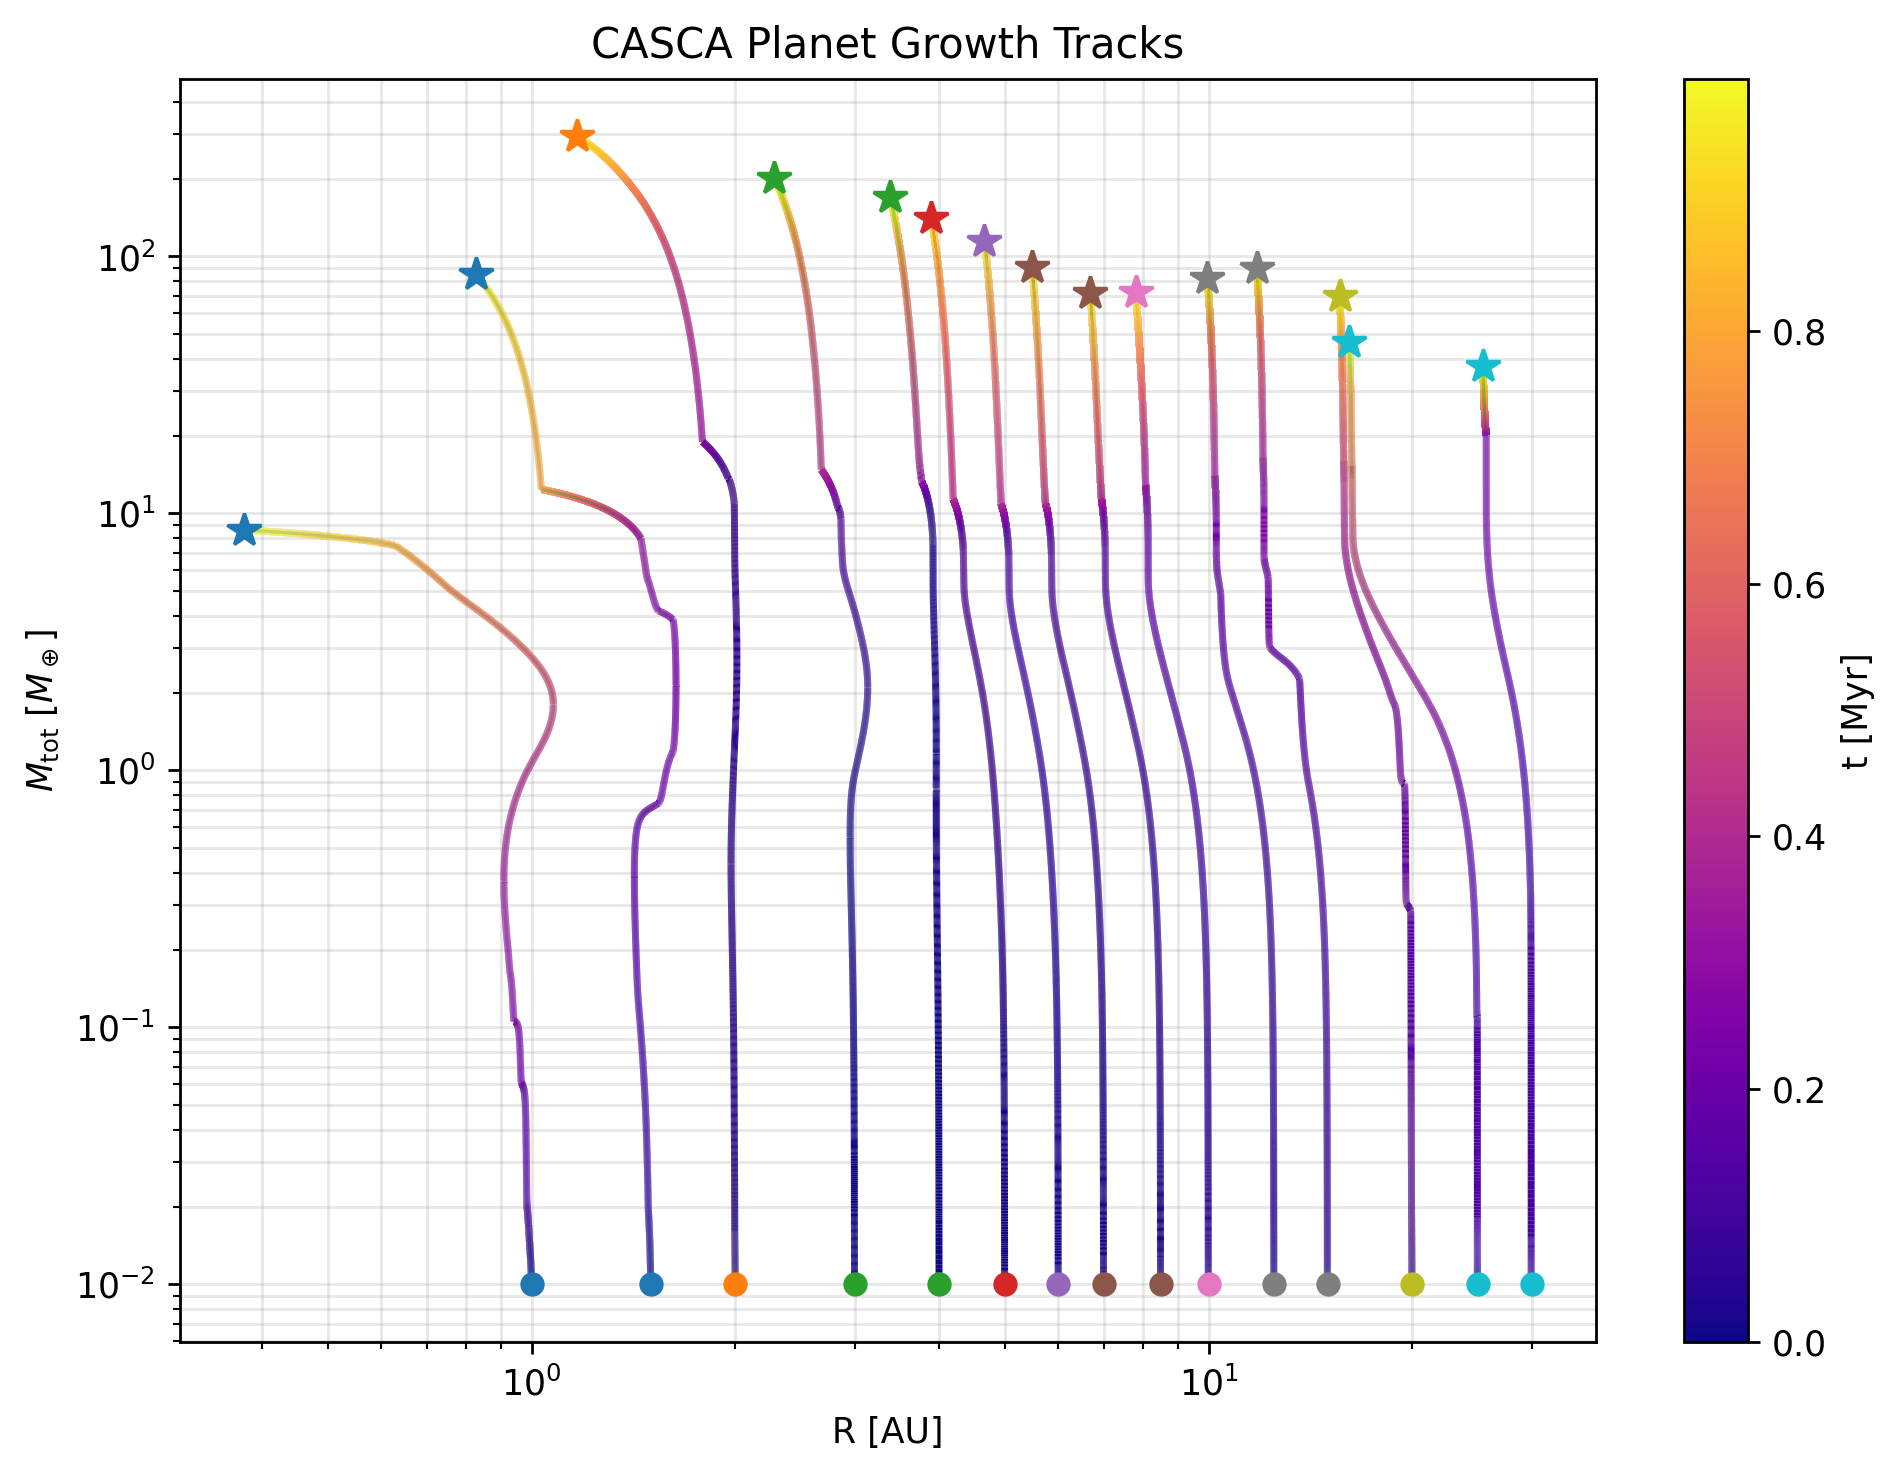

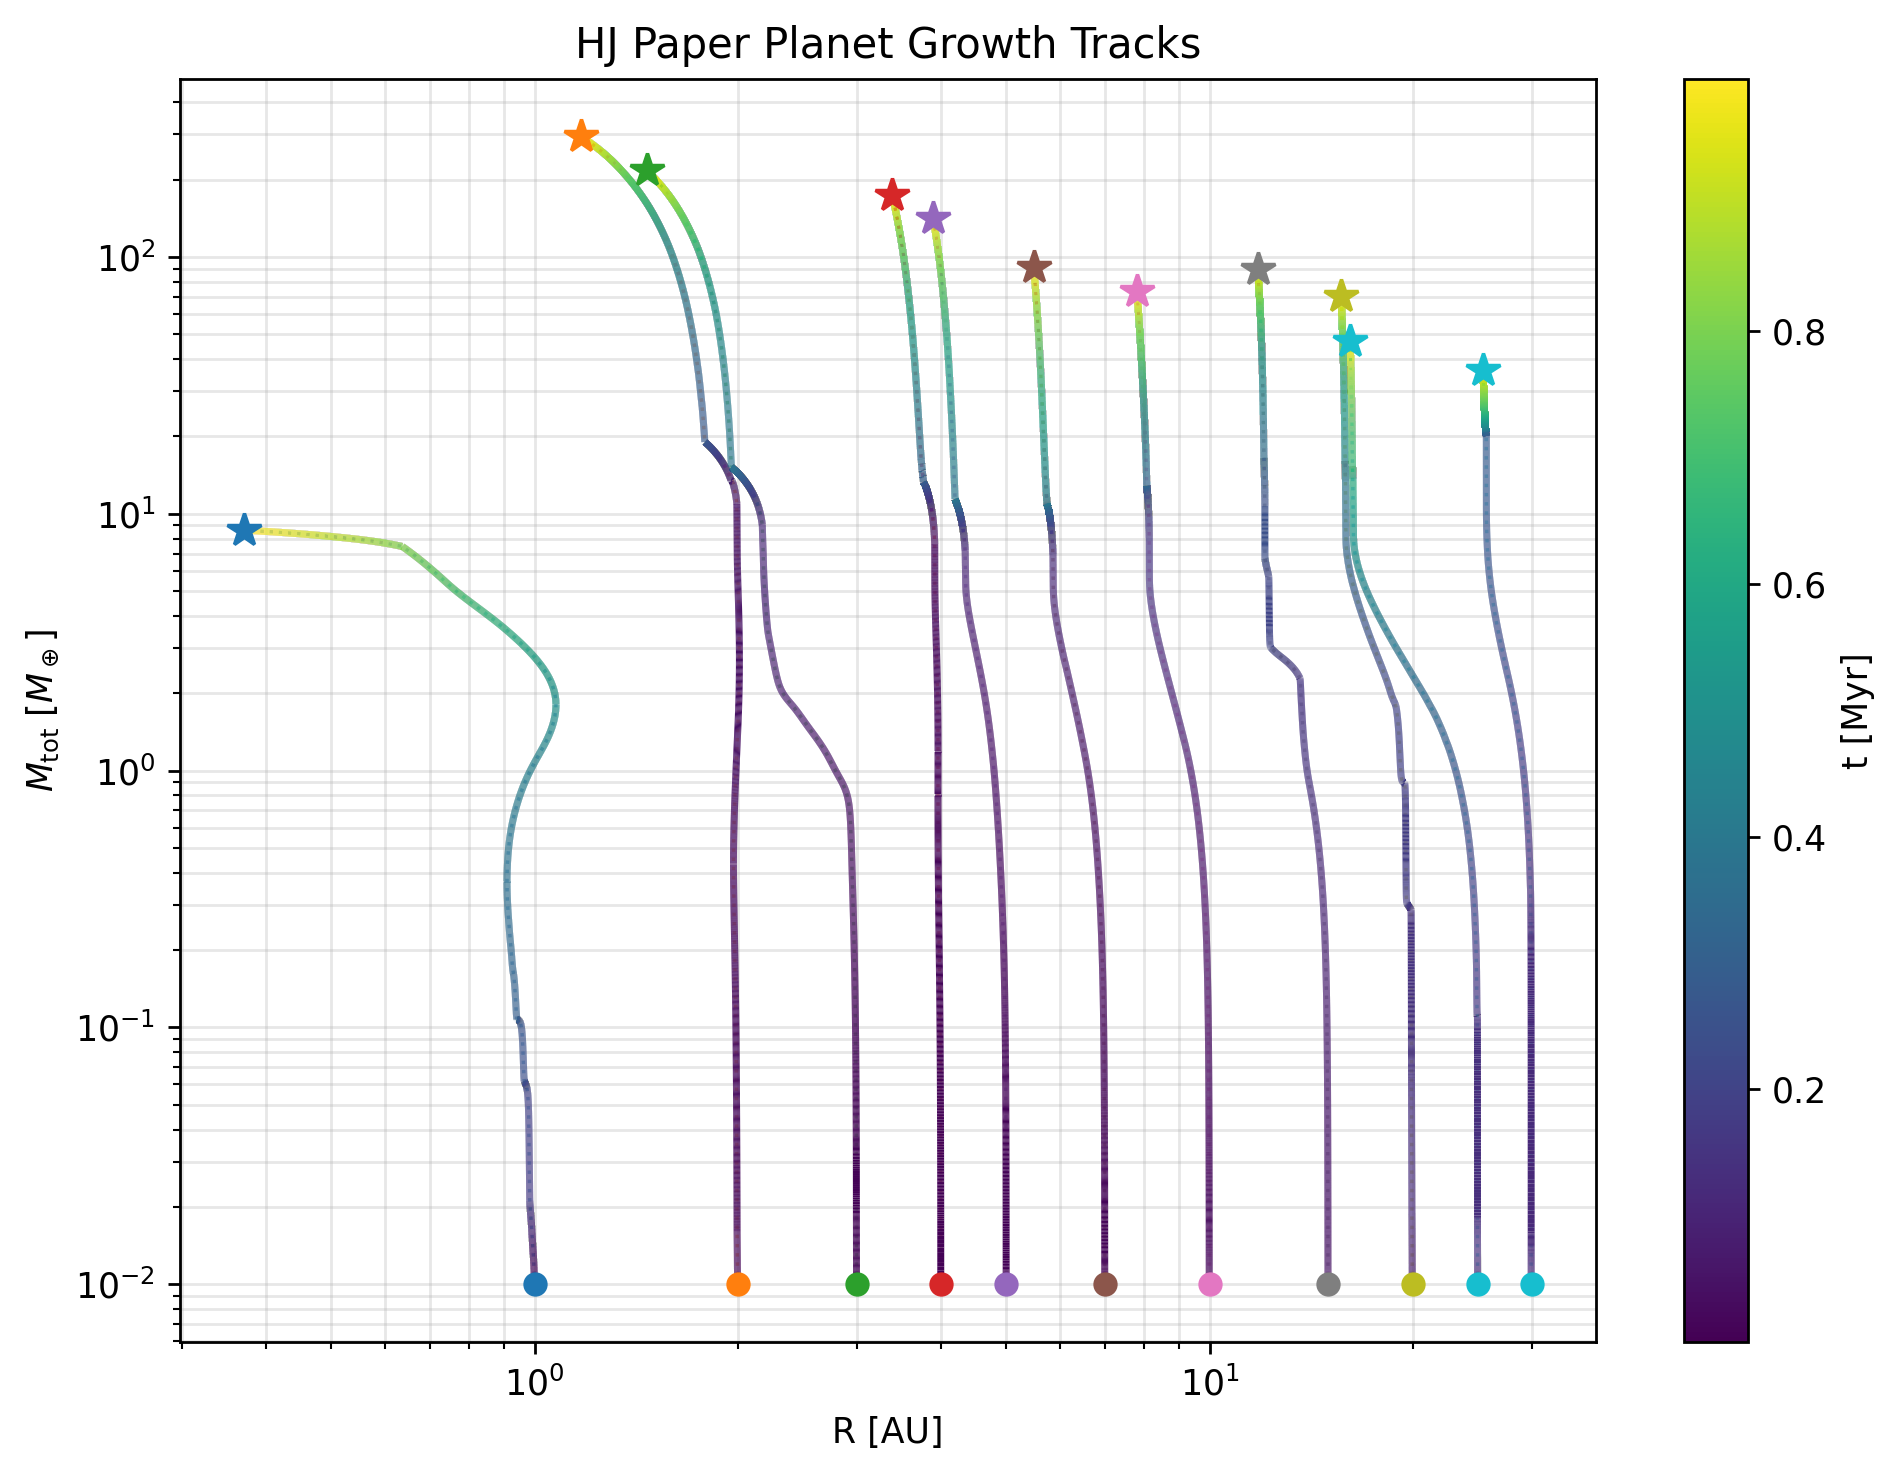

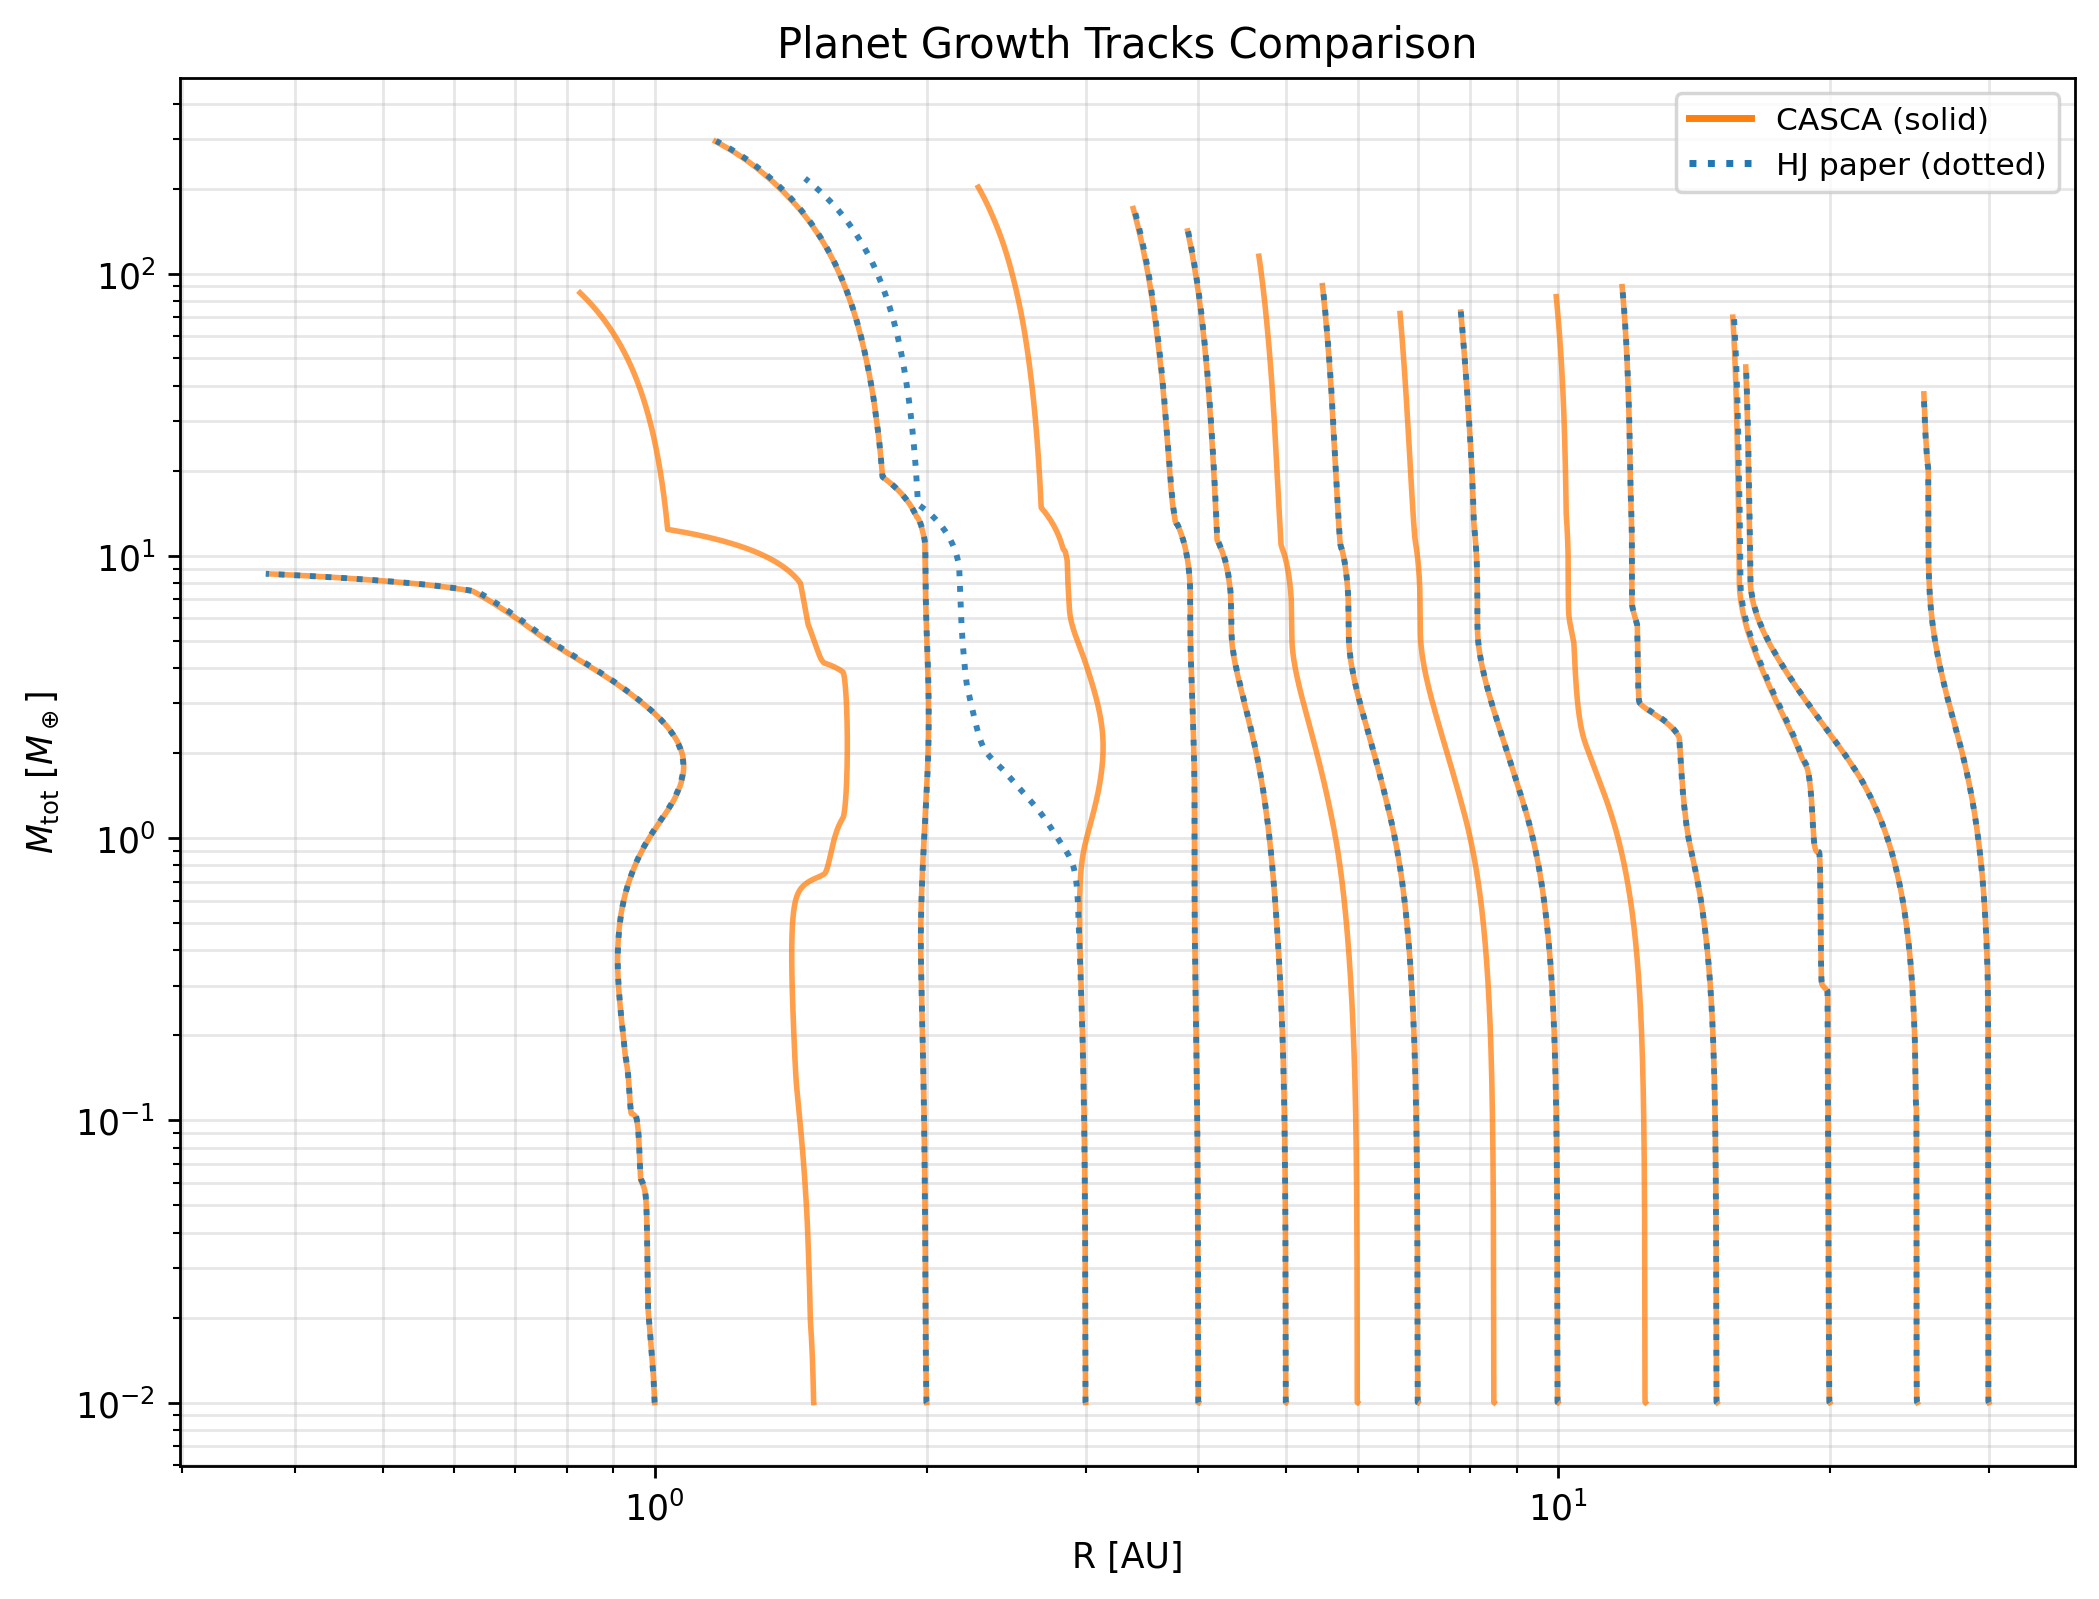

In [4]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# CASCA seed time used in the source run when planets are implanted.
# This sets the prepended 0.01 M_earth point color to the true seed time.
CASCA_SEED_TIME_YR = 0.06e6


def _load_casca_planet_tracks(h5_path):
    with h5py.File(h5_path, "r") as f:
        # Prefer the fine-cadence planet_log (starts at t0 with the exact implant
        # radii): smooth tracks and correctly pinned seed points.
        if "planet_log" in f and all(k in f["planet_log"] for k in ["R", "Mcore", "Menv"]):
            g = f["planet_log"]
            R = np.asarray(g["R"], dtype=float)
            Mcore = np.asarray(g["Mcore"], dtype=float)
            Menv = np.asarray(g["Menv"], dtype=float)
            t = np.asarray(g["t_yr"], dtype=float) if "t_yr" in g else None
            return {
                "R": R,
                "Mcore": Mcore,
                "Menv": Menv,
                "t_yr": t,
                "label": "CASCA",
                "seeded": True,   # already includes the t0 seed point
            }

        # Fallback: coarse per-output-time 'planets' group
        if "planets" not in f:
            return None
        g = f["planets"]
        if not all(k in g for k in ["R", "Mcore", "Menv"]):
            return None

        R = np.asarray(g["R"], dtype=float)
        Mcore = np.asarray(g["Mcore"], dtype=float)
        Menv = np.asarray(g["Menv"], dtype=float)
        first = int(g.attrs.get("first_snap", 0))

        t = np.asarray(f["t_yr"], dtype=float) if "t_yr" in f else None
        if t is not None:
            t = t[first:first + R.shape[0]]

        return {
            "R": R,
            "Mcore": Mcore,
            "Menv": Menv,
            "t_yr": t,
            "label": "CASCA",
        }


def _ensure_casca_seed_mass(track_data, seed_mass=0.01, seed_time_yr=CASCA_SEED_TIME_YR):
    """Prepend a seed point so each CASCA planet starts at 0.01 M_earth in plots."""
    if track_data is None:
        return None
    if track_data.get("label") != "CASCA":
        return track_data
    if track_data.get("seeded"):
        # planet_log already includes the t0 seed point at the exact implant radius
        return track_data

    R = np.asarray(track_data["R"], dtype=float)
    Mcore = np.asarray(track_data["Mcore"], dtype=float)
    Menv = np.asarray(track_data["Menv"], dtype=float)
    t = None if track_data.get("t_yr") is None else np.asarray(track_data["t_yr"], dtype=float)

    if R.ndim != 2 or Mcore.shape != R.shape or Menv.shape != R.shape:
        return track_data

    n_planets = R.shape[1]

    # Use first available orbital radius per planet for the seed point.
    seed_R = R[:1, :].copy()
    for j in range(n_planets):
        if not np.isfinite(seed_R[0, j]) or seed_R[0, j] <= 0:
            valid = np.where(np.isfinite(R[:, j]) & (R[:, j] > 0))[0]
            seed_R[0, j] = R[valid[0], j] if len(valid) else np.nan

    seed_Mcore = np.full((1, n_planets), float(seed_mass), dtype=float)
    seed_Menv = np.zeros((1, n_planets), dtype=float)

    R_new = np.vstack([seed_R, R])
    Mcore_new = np.vstack([seed_Mcore, Mcore])
    Menv_new = np.vstack([seed_Menv, Menv])

    if t is not None and len(t) > 0:
        # Anchor seed color/time at implantation (e.g. 0.06 Myr), not first saved snapshot.
        t_new = np.concatenate([[float(seed_time_yr)], t])
    else:
        t_new = t

    return {
        "R": R_new,
        "Mcore": Mcore_new,
        "Menv": Menv_new,
        "t_yr": t_new,
        "label": "CASCA",
    }


def _read_h5_planet_group_as_2d(group):
    """Read HDF5 group with per-planet arrays into shape (ntime, nplanet)."""
    keys = sorted(group.keys(), key=lambda x: int(x) if str(x).isdigit() else str(x))
    if len(keys) == 0:
        return None

    tracks = [np.asarray(group[k], dtype=float).ravel() for k in keys]
    min_len = min(len(a) for a in tracks)
    if min_len == 0:
        return None

    # Trim to common length so planets align in time.
    tracks = [a[:min_len] for a in tracks]
    return np.column_stack(tracks)


def _load_hj_planet_tracks(h5_path):
    """Load HJ planet tracks from either legacy Rp/Mcs/Mes groups or planets group."""
    with h5py.File(h5_path, "r") as f:
        # Legacy HJ format: top-level groups Rp, Mcs, Mes with per-planet arrays.
        if all(k in f and isinstance(f[k], h5py.Group) for k in ["Rp", "Mcs", "Mes"]):
            R = _read_h5_planet_group_as_2d(f["Rp"])
            Mcore = _read_h5_planet_group_as_2d(f["Mcs"])
            Menv = _read_h5_planet_group_as_2d(f["Mes"])

            if R is not None and Mcore is not None and Menv is not None:
                ntime = min(R.shape[0], Mcore.shape[0], Menv.shape[0])
                nplanet = min(R.shape[1], Mcore.shape[1], Menv.shape[1])
                R = R[:ntime, :nplanet]
                Mcore = Mcore[:ntime, :nplanet]
                Menv = Menv[:ntime, :nplanet]

                if "t" in f:
                    t = np.asarray(f["t"], dtype=float)
                elif "t_yr" in f:
                    t = np.asarray(f["t_yr"], dtype=float)
                elif "time_snap" in f:
                    t = np.asarray(f["time_snap"], dtype=float) * 1e6
                else:
                    t = None

                if t is not None:
                    t = t[:ntime]

                return {
                    "R": R,
                    "Mcore": Mcore,
                    "Menv": Menv,
                    "t_yr": t,
                    "label": "HJ",
                }

        # Alternate format: planets group with R/Mcore/Menv datasets.
        if "planets" in f:
            g = f["planets"]
            if all(k in g for k in ["R", "Mcore", "Menv"]):
                R = np.asarray(g["R"], dtype=float)
                Mcore = np.asarray(g["Mcore"], dtype=float)
                Menv = np.asarray(g["Menv"], dtype=float)

                if "t" in f:
                    t = np.asarray(f["t"], dtype=float)
                elif "t_yr" in f:
                    t = np.asarray(f["t_yr"], dtype=float)
                elif "time_snap" in f:
                    t = np.asarray(f["time_snap"], dtype=float) * 1e6
                else:
                    t = None

                first = int(g.attrs.get("first_snap", 0))
                if t is not None:
                    t = t[first:first + R.shape[0]]

                return {
                    "R": R,
                    "Mcore": Mcore,
                    "Menv": Menv,
                    "t_yr": t,
                    "label": "HJ",
                }

    return None


def _plot_tracks_single(track_data, title, line_style="-", cmap_name="plasma"):
    fig, ax = plt.subplots(figsize=(8, 6), dpi=250)

    if track_data is None:
        ax.text(0.5, 0.5, "No planet growth tracks found in this file", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        ax.set_axis_off()
        plt.show()
        return

    R = track_data["R"]
    Mtot = track_data["Mcore"] + track_data["Menv"]
    t = track_data["t_yr"]

    n_planets = R.shape[1]
    colors = plt.cm.tab10(np.linspace(0, 1, max(n_planets, 1)))

    if t is None or len(t) == 0:
        t = np.arange(R.shape[0], dtype=float)
        cbar_label = "snapshot index"
    else:
        cbar_label = "t [Myr]"

    t_plot = t / 1e6 if cbar_label == "t [Myr]" else t
    norm = Normalize(vmin=t_plot[0], vmax=t_plot[-1] if len(t_plot) > 1 else t_plot[0] + 1)

    for i in range(n_planets):
        R_track = R[:, i]
        M_track = Mtot[:, i]

        valid = np.isfinite(R_track) & np.isfinite(M_track) & (R_track > 0) & (M_track > 0)
        R_track = R_track[valid]
        M_track = M_track[valid]
        t_track = t_plot[valid]

        if len(R_track) < 2:
            continue

        ax.plot(R_track, M_track, line_style, color=colors[i], lw=1.0, alpha=0.45, zorder=2)

        points = np.array([R_track, M_track]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=cmap_name, norm=norm, linewidth=2.0, zorder=3)
        lc.set_array(t_track[:-1])
        ax.add_collection(lc)

        ax.plot(R_track[0], M_track[0], "o", color=colors[i], ms=6, zorder=5)
        ax.plot(R_track[-1], M_track[-1], "*", color=colors[i], ms=10, zorder=5)

    sm = cm.ScalarMappable(cmap=cmap_name, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label=cbar_label)

    ax.autoscale()
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("R [AU]")
    ax.set_ylabel(r"$M_{\rm tot}$ [$M_\oplus$]")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()


def _plot_tracks_combined(casca_data, hj_data):
    fig, ax = plt.subplots(figsize=(8.5, 6.5), dpi=250)

    plotted_any = False

    # CASCA: solid
    if casca_data is not None:
        R = casca_data["R"]
        Mtot = casca_data["Mcore"] + casca_data["Menv"]
        for i in range(R.shape[1]):
            valid = np.isfinite(R[:, i]) & np.isfinite(Mtot[:, i]) & (R[:, i] > 0) & (Mtot[:, i] > 0)
            if np.count_nonzero(valid) >= 2:
                ax.plot(R[valid, i], Mtot[valid, i], "-", color="C1", alpha=0.75, lw=1.6)
                plotted_any = True

    # HJ: dotted
    if hj_data is not None:
        R = hj_data["R"]
        Mtot = hj_data["Mcore"] + hj_data["Menv"]
        for i in range(R.shape[1]):
            valid = np.isfinite(R[:, i]) & np.isfinite(Mtot[:, i]) & (R[:, i] > 0) & (Mtot[:, i] > 0)
            if np.count_nonzero(valid) >= 2:
                ax.plot(R[valid, i], Mtot[valid, i], ":", color="C0", alpha=0.9, lw=1.7)
                plotted_any = True

    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color="C1", lw=2, linestyle="-", label="CASCA (solid)"),
        Line2D([0], [0], color="C0", lw=2, linestyle=":", label="HJ paper (dotted)"),
    ]
    ax.legend(handles=legend_handles, fontsize=9)

    if not plotted_any:
        ax.text(0.5, 0.5, "No plottable planet tracks found", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        plt.show()
        return

    if hj_data is None:
        ax.text(0.02, 0.03, "Note: HJ file has no numeric planet-track datasets", transform=ax.transAxes, fontsize=9)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("R [AU]")
    ax.set_ylabel(r"$M_{\rm tot}$ [$M_\oplus$]")
    ax.set_title("Planet Growth Tracks Comparison")
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()


# Load tracks from the two datasets used above
casca_tracks = _load_casca_planet_tracks(casca_run["path"])
casca_tracks = _ensure_casca_seed_mass(casca_tracks, seed_mass=0.01, seed_time_yr=CASCA_SEED_TIME_YR)
hj_tracks = _load_hj_planet_tracks(hj_run["path"])

# 1) CASCA only
_plot_tracks_single(casca_tracks, title="CASCA Planet Growth Tracks", line_style="-", cmap_name="plasma")

# 2) HJ only
_plot_tracks_single(hj_tracks, title="HJ Paper Planet Growth Tracks", line_style=":", cmap_name="viridis")

# 3) Combined: CASCA solid, HJ dotted
_plot_tracks_combined(casca_tracks, hj_tracks)